# Genie Agent Evaluation Harness

A programmatic framework for **testing and improving** Databricks Genie Agents (formerly Genie Spaces) — the natural-language "Ask Your Data" interface, accessible standalone or via **Genie One**.

## What this notebook covers

| Step | What happens |
|---|---|
| 1. **Ask** | Submit questions to a Genie Agent via the Conversation API |
| 2. **Compare** | Match generated SQL against expected ground-truth queries (Chat mode) |
| 3. **Score** | Use an LLM judge (MLflow) for semantic equivalence — not just exact-match |
| 4. **Iterate** | Track accuracy over time, identify failure patterns, improve instructions |

## Core Idea

> A Genie Agent without evaluation is a **hope-driven deployment**.  
> A Genie Agent *with* a harness is an **engineering-driven deployment**.

This implements the [Data Flywheel](https://www.sh-reya.com/blog/ai-engineering-flywheel/):  
**Evaluate → Identify failures → Improve → Re-evaluate → Ship with confidence**

---

## Getting Started

This notebook uses `samples.bakehouse` — a Databricks sample dataset available in every workspace. No additional data setup is required to run the default test suite.

To adapt it to your own Genie Agent:
1. Set `SPACE_ID` in the **Configuration** cell (from the URL: `.../genie/rooms/<SPACE_ID>`)
2. Replace `test_cases` in the **Test Suite** cell with questions and expected SQL for your data model
3. Run all cells sequentially

> **Terminology note (July 2026):** Databricks renamed *Genie Spaces* to **Genie Agents** and introduced the **Genie Ontology** (the structured knowledge layer: instructions, example SQL, join specs, synonyms, and prompt matching). The underlying Conversation API (`/api/2.0/genie/spaces/`) remains unchanged — so this harness works as-is against both the legacy and new naming. Native **Benchmarks** now exist in the Genie UI for lightweight testing; this notebook adds MLflow-tracked semantic scoring, CI/CD embeddability, and full control over the judge prompt.

The `genie-ontology/` folder shows the ontology-as-code pattern in action: versioned instructions, example SQL, and join specifications that can be reviewed and diffed alongside the test suite.

## Prerequisites

**Who is this for?**  
Data engineers, analysts, and platform teams who deploy or manage Genie Agents and want to ensure answer quality before going live.

**What you need:**

| Requirement | Details |
|---|---|
| Databricks workspace | With access to a SQL warehouse |
| A Genie Agent | Any Agent (formerly Space) — we use the `samples.bakehouse` dataset as an example |
| Python basics | Comfortable reading Python; no ML expertise required |
| MLflow (optional) | Pre-installed on Databricks ML Runtime; used for LLM-as-judge scoring |



In [0]:
%pip install mlflow -q
dbutils.library.restartPython()

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-server 1.23.4 requires anyio<4,>=3.1.0, but you have anyio 4.14.1 which is incompatible.
googleapis-common-protos 1.62.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0.dev0,>=3.19.5, but you have protobuf 7.35.1 which is incompatible.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Setup & Imports
# ================
# Core SDK and evaluation libraries for interacting with Genie Agents
# (formerly Genie Spaces) and scoring results programmatically.

from databricks.sdk import WorkspaceClient
try:    import mlflow
except ModuleNotFoundError:
    print('mlflow module is not installed. Please install it to use related functionalities.')

try:    import mlflow.genai
except ModuleNotFoundError:
    print('mlflow.genai module is not installed. Please install mlflow with genai support.')

from mlflow.genai import make_judge
import pandas as pd
import time
import json
from datetime import datetime

# Initialize the Databricks Workspace Client
# (Automatically authenticated when running on Databricks compute)
w = WorkspaceClient()

print(f"✓ Workspace client initialized")
print(f"  Host: {w.config.host}")
print(f"  Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Workspace client initialized
  Host: https://adb-4435273560031080.0.azuredatabricks.net
  Timestamp: 2026-07-08 13:41:34


ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/databricks/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 536, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
  File "/usr/lib/python3.10/socket.py", line 705, in readinto
    return self._sock.recv_into(b)
ConnectionResetError: [Errno 104] Connection reset by peer

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/databricks/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/databricks/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 564, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending or receiving


In [0]:
# Configuration
# =============
# Set your Genie Agent ID and evaluation parameters here.

# ─── Genie Agent ID (still called "space" in the API) ────────────────────────
# Find this in your Genie Agent URL:
#   https://<workspace>.databricks.com/genie/rooms/<SPACE_ID>
# Or via the API: GET /api/2.0/genie/spaces
SPACE_ID = "01f16364ce181c628265e3815d9214cc"  # Bakehouse Analytics

# ─── Polling Configuration ────────────────────────────────────────────────────
# Genie processes questions asynchronously. We poll until the answer is ready.
POLL_INTERVAL_SECONDS = 3   # Seconds between status checks
MAX_POLL_ATTEMPTS = 60      # Maximum polls before timeout (= 3 min total)

# ─── MLflow Experiment ────────────────────────────────────────────────────────
# All evaluation runs are logged here for tracking improvement over time.
EXPERIMENT_NAME = "/Users/niklas.niggemann@codecentric.de/genie-eval-experiment"
mlflow.set_experiment(EXPERIMENT_NAME)

# ─── Validation ───────────────────────────────────────────────────────────────
assert SPACE_ID, (
    "⚠️  Please set SPACE_ID above before running the evaluation. "
    "You can find it in your Genie Agent URL."
)
print(f"✓ Configuration loaded")
print(f"  Space ID: {SPACE_ID}")
print(f"  Timeout:  {POLL_INTERVAL_SECONDS * MAX_POLL_ATTEMPTS}s")
print(f"  Experiment: {EXPERIMENT_NAME}")

2026/07/08 13:41:39 INFO mlflow.tracking.fluent: Experiment with name '/Users/niklas.niggemann@codecentric.de/genie-eval-experiment' does not exist. Creating a new experiment.


✓ Configuration loaded
  Space ID: 01f16364ce181c628265e3815d9214cc
  Timeout:  180s
  Experiment: /Users/niklas.niggemann@codecentric.de/genie-eval-experiment


If you are using MLflow Tracing, consider storing your traces in Unity Catalog for unlimited storage (no 100,000 trace limit), fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/trace-unity-catalog


In [0]:
# Genie API Helpers
# =================
# Functions to interact with Genie Agents programmatically via the REST API.
# (The API still uses /genie/spaces/ in the path — the rename is UI-only.)
# We use the Databricks SDK's api_client for authenticated requests.

def ask_genie(space_id: str, question: str) -> dict:
    """
    Submit a natural-language question to a Genie Agent and wait for the response.
    
    Uses the Genie Conversation API:
      1. POST /start-conversation to submit the question
      2. Poll GET /messages/{id} until status leaves IN_PROGRESS/EXECUTING_QUERY
    
    Args:
        space_id: The Genie Agent ID (from the URL or API)
        question: Natural-language question to ask
    
    Returns:
        dict with keys: status, message, conversation_id, message_id, elapsed_seconds
    """
    start_time = time.time()
    
    # Step 1: Start a new conversation with the question
    response = w.api_client.do(
        method="POST",
        path=f"/api/2.0/genie/spaces/{space_id}/start-conversation",
        body={"content": question}
    )
    
    conversation_id = response["conversation_id"]
    message_id = response["message_id"]
    
    # Step 2: Poll until the message is ready
    # Only stop polling when we reach a terminal status.
    # Any other status (FETCHING_METADATA, PENDING_WAREHOUSE, SUBMITTED,
    # FILTERING_CONTEXT, ASKING_AI, GENERATING_SQL, EXECUTING_QUERY, etc.)
    # means Genie is still working.
    terminal_statuses = {"COMPLETED", "FAILED", "CANCELLED", "QUERY_RESULT_EXPIRED"}
    
    for attempt in range(MAX_POLL_ATTEMPTS):
        msg_response = w.api_client.do(
            method="GET",
            path=f"/api/2.0/genie/spaces/{space_id}/conversations/{conversation_id}/messages/{message_id}"
        )
        
        status = msg_response.get("status", "UNKNOWN")
        
        if status in terminal_statuses:
            elapsed = time.time() - start_time
            return {
                "status": status,
                "message": msg_response,
                "conversation_id": conversation_id,
                "message_id": message_id,
                "elapsed_seconds": round(elapsed, 2)
            }
        
        time.sleep(POLL_INTERVAL_SECONDS)
    
    # Timeout reached
    elapsed = time.time() - start_time
    return {
        "status": "TIMEOUT",
        "message": msg_response,
        "conversation_id": conversation_id,
        "message_id": message_id,
        "elapsed_seconds": round(elapsed, 2)
    }


def extract_sql(message: dict) -> str:
    """
    Extract the generated SQL from a Genie message response.
    
    Genie returns SQL in attachments[].query.query (the field is named 'query',
    not 'sql').
    
    Returns:
        The generated SQL string, or empty string if not found.
    """
    msg_data = message.get("message", message)
    attachments = msg_data.get("attachments", []) or []
    
    for attachment in attachments:
        if "query" in attachment:
            query_info = attachment["query"]
            # Primary field: 'query' contains the SQL
            if "query" in query_info:
                return query_info["query"]
            # Fallback: some versions may use 'sql'
            if "sql" in query_info:
                return query_info["sql"]
    
    return ""


def extract_result(message: dict) -> list:
    """
    Extract query result rows from a Genie message response.
    
    Returns:
        List of result rows (each row is a dict), or empty list if no results.
    """
    msg_data = message.get("message", message)
    attachments = msg_data.get("attachments", []) or []
    
    for attachment in attachments:
        if "query" in attachment:
            query_info = attachment["query"]
            # Results may be nested under query_result or result
            if "query_result" in query_info:
                result = query_info["query_result"]
                if "data" in result:
                    return result["data"]
                return result
            if "result" in query_info:
                return query_info["result"]
    
    # Check top-level query_result
    if "query_result" in msg_data:
        qr = msg_data["query_result"]
        if isinstance(qr, dict) and "data" in qr:
            return qr["data"]
        return qr if isinstance(qr, list) else []
    
    return []


def extract_text_response(message: dict) -> str:
    """
    Extract Genie's narrative text response (not the user's input question).
    
    Genie's text reply is in attachments[].text.content, while the top-level
    'content' field is the user's original question.
    """
    msg_data = message.get("message", message)
    attachments = msg_data.get("attachments", []) or []
    
    for attachment in attachments:
        if "text" in attachment:
            text_info = attachment["text"]
            if "content" in text_info:
                return text_info["content"]
    
    # Fallback: return empty if no text attachment found
    return ""


print("✓ Genie API helper functions defined")
print("  • ask_genie(space_id, question) → polls until response ready")
print("  • extract_sql(message) → generated SQL string")
print("  • extract_result(message) → query result rows")
print("  • extract_text_response(message) → narrative text")

✓ Genie API helper functions defined
  • ask_genie(space_id, question) → polls until response ready
  • extract_sql(message) → generated SQL string
  • extract_result(message) → query result rows
  • extract_text_response(message) → narrative text


In [0]:
# Quick Start — Single Question
# ==============================
# Run this cell to try a single question before running the full evaluation suite.
# Useful for verifying connectivity to your Genie Agent,
# or for inspecting the raw response structure.

DEMO_QUESTION = "What are the top 5 best-selling products?"

print(f"Asking Genie: '{DEMO_QUESTION}'")
print("Waiting for response...\n")

demo_result = ask_genie(SPACE_ID, DEMO_QUESTION)

# ─── Walk through the response structure ─────────────────────────────────────
print("="*60)
print(" RESPONSE ANATOMY")
print("="*60)
print(f"\n  Status:        {demo_result['status']}")
print(f"  Response time: {demo_result['elapsed_seconds']}s")
print(f"  Conv. ID:      {demo_result['conversation_id'][:12]}...")

generated_sql = extract_sql(demo_result)
text_response = extract_text_response(demo_result)
result_rows = extract_result(demo_result)

if generated_sql:
    print(f"\n  ┌─ Generated SQL ({'✓' if generated_sql else '✗'}) ─────────────────────")
    for line in generated_sql.strip().split('\n'):
        print(f"  │  {line}")
    print(f"  └{'─'*50}")

if text_response:
    print(f"\n  Text response: {text_response[:150]}")

if result_rows:
    print(f"\n  Result preview ({len(result_rows)} rows):")
    for row in result_rows[:5]:
        print(f"    {row}")
    if len(result_rows) > 5:
        print(f"    ... and {len(result_rows) - 5} more rows")

print("\n" + "─"*60)

Asking Genie: 'What are the top 5 best-selling products?'
Waiting for response...

 RESPONSE ANATOMY

  Status:        COMPLETED
  Response time: 31.35s
  Conv. ID:      01f17ad2c36d...

  ┌─ Generated SQL (✓) ─────────────────────
  │  WITH ranked_products AS (
  │    SELECT 
  │      `product`, 
  │      COUNT(*) AS transaction_count, 
  │      RANK() OVER (ORDER BY COUNT(*) DESC) AS rank
  │    FROM `samples`.`bakehouse`.`sales_transactions`
  │    WHERE `product` IS NOT NULL
  │    GROUP BY `product`
  │  )
  │  SELECT `product`, transaction_count
  │  FROM ranked_products
  │  WHERE rank <= 5
  │  ORDER BY transaction_count DESC, product ASC
  └──────────────────────────────────────────────────

  Text response: The **top 5 best-selling products** by transaction count are:
- **Golden Gate Ginger** (586 transactions)
- **Tokyo Tidbits** (583 transactions)
- **O

────────────────────────────────────────────────────────────


In [0]:
# Test Suite Definition
# =====================
# Define your benchmark test cases here. Each test case represents a question
# that a business user might ask, along with the expected correct answer.
#
# Customize these test cases for your Genie Agent and data model.
# A good test suite covers:
#   - Different question categories (aggregations, filters, joins, time-series)
#   - Edge cases (ambiguous phrasing, synonyms, boundary conditions)
#   - Questions of varying complexity

test_cases = [
    # ─── 1: Simple Aggregation ────────────────────────────────────────────────
    {
        "question": "What is the total revenue across all transactions?",
        "expected_sql": """
            SELECT SUM(totalPrice) AS total_revenue
            FROM samples.bakehouse.sales_transactions
        """,
        "expected_result_contains": None,
        "category": "aggregation",
        "difficulty": "easy"
    },
    # ─── 2: Filtered Aggregation ──────────────────────────────────────────────
    {
        "question": "How many transactions were paid with Visa?",
        "expected_sql": """
            SELECT COUNT(*) AS visa_transactions
            FROM samples.bakehouse.sales_transactions
            WHERE paymentMethod = 'visa'
        """,
        "expected_result_contains": "1083",
        "category": "filter",
        "difficulty": "easy"
    },
    # ─── 3: GROUP BY ──────────────────────────────────────────────────────────
    {
        "question": "What is the total revenue per product?",
        "expected_sql": """
            SELECT product, SUM(totalPrice) AS revenue
            FROM samples.bakehouse.sales_transactions
            GROUP BY product
            ORDER BY revenue DESC
        """,
        "expected_result_contains": None,
        "category": "aggregation",
        "difficulty": "easy"
    },
    # ─── 4: JOIN + Filter ─────────────────────────────────────────────────────
    {
        "question": "Show me total sales per franchise in Japan",
        "expected_sql": """
            SELECT f.name, SUM(t.totalPrice) AS total_sales
            FROM samples.bakehouse.sales_transactions t
            JOIN samples.bakehouse.sales_franchises f ON t.franchiseID = f.franchiseID
            WHERE f.country = 'Japan'
            GROUP BY f.name
            ORDER BY total_sales DESC
        """,
        "expected_result_contains": None,
        "category": "join",
        "difficulty": "medium"
    },
    # ─── 5: Multi-table JOIN ──────────────────────────────────────────────────
    {
        "question": "Which customers from Australia have spent the most in total?",
        "expected_sql": """
            SELECT c.first_name, c.last_name, SUM(t.totalPrice) AS total_spent
            FROM samples.bakehouse.sales_transactions t
            JOIN samples.bakehouse.sales_customers c ON t.customerID = c.customerID
            WHERE c.country = 'Australia'
            GROUP BY c.first_name, c.last_name
            ORDER BY total_spent DESC
        """,
        "expected_result_contains": None,
        "category": "join",
        "difficulty": "medium"
    },
    # ─── 6: Time-based query ──────────────────────────────────────────────────
    {
        "question": "What were the total sales in May 2024?",
        "expected_sql": """
            SELECT SUM(totalPrice) AS may_sales
            FROM samples.bakehouse.sales_transactions
            WHERE dateTime >= '2024-05-01' AND dateTime < '2024-06-01'
        """,
        "expected_result_contains": None,
        "category": "time_filter",
        "difficulty": "medium"
    },
    # ─── 7: Ambiguous phrasing (robustness test) ──────────────────────────────
    {
        "question": "What's the most popular product?",
        "expected_sql": """
            SELECT product, COUNT(*) AS transaction_count
            FROM samples.bakehouse.sales_transactions
            GROUP BY product
            ORDER BY transaction_count DESC
            LIMIT 1
        """,
        "expected_result_contains": "Golden Gate Ginger",
        "category": "ambiguous",
        "difficulty": "medium"
    },
    # ─── 8: Complex multi-hop JOIN ────────────────────────────────────────────
    {
        "question": "Which supplier provides ingredients to the franchise with the highest revenue?",
        "expected_sql": """
            SELECT s.name AS supplier_name, s.ingredient,
                   f.name AS franchise_name, SUM(t.totalPrice) AS franchise_revenue
            FROM samples.bakehouse.sales_transactions t
            JOIN samples.bakehouse.sales_franchises f ON t.franchiseID = f.franchiseID
            JOIN samples.bakehouse.sales_suppliers s ON f.supplierID = s.supplierID
            GROUP BY s.name, s.ingredient, f.name
            ORDER BY franchise_revenue DESC
            LIMIT 1
        """,
        "expected_result_contains": None,
        "category": "join",
        "difficulty": "hard"
    },
]

# ─── Validation ───────────────────────────────────────────────────────────────
print(f"✓ Test suite loaded: {len(test_cases)} test cases")
for i, tc in enumerate(test_cases, 1):
    print(f"  [{i}] ({tc['category']}/{tc['difficulty']}) {tc['question'][:60]}...")

✓ Test suite loaded: 8 test cases
  [1] (aggregation/easy) What is the total revenue across all transactions?...
  [2] (filter/easy) How many transactions were paid with Visa?...
  [3] (aggregation/easy) What is the total revenue per product?...
  [4] (join/medium) Show me total sales per franchise in Japan...
  [5] (join/medium) Which customers from Australia have spent the most in total?...
  [6] (time_filter/medium) What were the total sales in May 2024?...
  [7] (ambiguous/medium) What's the most popular product?...
  [8] (join/hard) Which supplier provides ingredients to the franchise with th...


In [0]:
# Run Evaluation
# ==============
# Execute each test case against the Genie Agent and collect results.
# This is the core evaluation loop that drives the harness.

print("\n" + "="*70)
print(" GENIE AGENT EVALUATION RUN")
print(f" Space: {SPACE_ID}")
print(f" Test cases: {len(test_cases)}")
print(f" Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70 + "\n")

eval_records = []

for i, test_case in enumerate(test_cases, 1):
    question = test_case["question"]
    print(f"[{i}/{len(test_cases)}] ▶ {question}")
    
    try:
        # Ask Genie the question
        result = ask_genie(SPACE_ID, question)
        
        # Extract outputs
        generated_sql = extract_sql(result)
        query_results = extract_result(result)
        text_response = extract_text_response(result)
        status = result["status"]
        elapsed = result["elapsed_seconds"]
        
        # Determine if result contains expected value (if specified)
        result_match = None
        if test_case.get("expected_result_contains"):
            result_str = json.dumps(query_results)
            result_match = test_case["expected_result_contains"] in result_str
        
        record = {
            "question": question,
            "category": test_case["category"],
            "difficulty": test_case["difficulty"],
            "status": status,
            "generated_sql": generated_sql.strip() if generated_sql else "",
            "expected_sql": test_case.get("expected_sql", "").strip(),
            "text_response": text_response[:200] if text_response else "",
            "result_preview": json.dumps(query_results[:3]) if query_results else "[]",
            "result_contains_expected": result_match,
            "execution_time_seconds": elapsed,
            "conversation_id": result["conversation_id"],
            "message_id": result["message_id"],
        }
        
        # Status indicator
        if status == "COMPLETED" and generated_sql:
            print(f"       ✓ Completed in {elapsed}s | SQL generated ({len(generated_sql)} chars)")
        elif status == "COMPLETED":
            print(f"       ✓ Completed in {elapsed}s | Text response (no SQL)")
        else:
            print(f"       ✗ {status} after {elapsed}s")
            
    except Exception as e:
        record = {
            "question": question,
            "category": test_case["category"],
            "difficulty": test_case["difficulty"],
            "status": "ERROR",
            "generated_sql": "",
            "expected_sql": test_case.get("expected_sql", "").strip(),
            "text_response": str(e)[:200],
            "result_preview": "[]",
            "result_contains_expected": None,
            "execution_time_seconds": 0,
            "conversation_id": "",
            "message_id": "",
        }
        print(f"       ✗ ERROR: {str(e)[:80]}")
    
    eval_records.append(record)
    print()

# Build the evaluation DataFrame
eval_results = pd.DataFrame(eval_records)

print("\n" + "="*70)
print(f" EVALUATION COMPLETE — {len(eval_results)} questions processed")
print(f" Finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

display(eval_results[["question", "category", "status", "execution_time_seconds"]].head(20))


 GENIE SPACE EVALUATION RUN
 Space: 01f16364ce181c628265e3815d9214cc
 Test cases: 8
 Started: 2026-07-08 13:42:22

[1/8] ▶ What is the total revenue across all transactions?
       ✓ Completed in 6.31s | SQL generated (89 chars)

[2/8] ▶ How many transactions were paid with Visa?
       ✓ Completed in 6.28s | SQL generated (154 chars)

[3/8] ▶ What is the total revenue per product?
       ✓ Completed in 9.35s | SQL generated (163 chars)

[4/8] ▶ Show me total sales per franchise in Japan
       ✓ Completed in 9.37s | SQL generated (234 chars)

[5/8] ▶ Which customers from Australia have spent the most in total?
       ✓ Completed in 15.49s | SQL generated (445 chars)

[6/8] ▶ What were the total sales in May 2024?
       ✓ Completed in 9.35s | SQL generated (208 chars)

[7/8] ▶ What's the most popular product?
       ✓ Completed in 12.45s | SQL generated (306 chars)

[8/8] ▶ Which supplier provides ingredients to the franchise with the highest revenue?
       ✓ Completed in 30.79s | S

question,category,status,execution_time_seconds
What is the total revenue across all transactions?,aggregation,COMPLETED,6.31
How many transactions were paid with Visa?,filter,COMPLETED,6.28
What is the total revenue per product?,aggregation,COMPLETED,9.35
Show me total sales per franchise in Japan,join,COMPLETED,9.37
Which customers from Australia have spent the most in total?,join,COMPLETED,15.49
What were the total sales in May 2024?,time_filter,COMPLETED,9.35
What's the most popular product?,ambiguous,COMPLETED,12.45
Which supplier provides ingredients to the franchise with the highest revenue?,join,COMPLETED,30.79


In [0]:
# MLflow Scoring with Custom Judge
# =================================
# Use an LLM judge to evaluate semantic SQL correctness.
# This goes beyond exact-match: two SQL statements can be syntactically different
# but semantically equivalent (producing the same result set).

# ─── Define Custom Judge ──────────────────────────────────────────────────────
# The judge evaluates whether generated SQL is semantically equivalent to the
# expected SQL, considering: same tables, same logic, same result set.

SQL_JUDGE_INSTRUCTIONS = """
You are an expert SQL evaluator for Databricks SQL. Determine whether the
generated SQL in {{ outputs }} is semantically equivalent to the expected SQL
in {{ expectations }} — meaning they would produce the same result set.

Two SQL statements are semantically equivalent if they:
1. Query the same tables (possibly with different aliases)
2. Apply the same filters (possibly in different order or syntax)
3. Produce the same columns with the same aggregation logic
4. Return the same rows (ordering differences are acceptable unless LIMIT is used)

Acceptable differences (still rate True):
- Different column aliases, join syntax, whitespace, equivalent date functions

Must match (rate False if different):
- Different tables, different aggregation functions (SUM vs COUNT),
  missing/extra filter conditions, different GROUP BY columns, different LIMIT values

The original question asked was: {{ inputs }}

Rate True if the generated SQL would produce equivalent results to the expected SQL.
Rate False if they would produce meaningfully different results.
"""

sql_correctness_judge = make_judge(
    name="sql_semantic_correctness",
    instructions=SQL_JUDGE_INSTRUCTIONS,
    model="databricks:/databricks-claude-sonnet-4",
    feedback_value_type=bool,
)

# ─── Prepare Evaluation Data ─────────────────────────────────────────────────
# Filter to only cases where we have both generated and expected SQL
eval_with_sql = eval_results[
    (eval_results["generated_sql"] != "") & 
    (eval_results["expected_sql"] != "")
].copy()

if len(eval_with_sql) == 0:
    print("⚠️  No test cases have both generated SQL and expected SQL.")
    print("   Ensure your test cases ran successfully and have expected_sql defined.")
else:
    print(f"✓ Evaluating {len(eval_with_sql)} test cases with SQL judge...")
    
    # Build the evaluation dataset for MLflow
    # Column names must match template variables: inputs, outputs, expectations
    # 'expectations' must be a dict column with named fields
    eval_data = pd.DataFrame({
        "inputs": [{"question": q} for q in eval_with_sql["question"].tolist()],
        "outputs": eval_with_sql["generated_sql"].tolist(),
        "expectations": [{"expected_sql": sql} for sql in eval_with_sql["expected_sql"].tolist()],
    })
    
    # Run MLflow GenAI evaluation with our custom judge
    with mlflow.start_run(run_name=f"genie-eval-{datetime.now().strftime('%Y%m%d-%H%M%S')}") as run:
        # Log evaluation metadata
        mlflow.log_param("space_id", SPACE_ID)
        mlflow.log_param("num_test_cases", len(test_cases))
        mlflow.log_param("num_evaluated", len(eval_with_sql))
        mlflow.log_param("eval_timestamp", datetime.now().isoformat())
        
        # Run the LLM judge evaluation
        judge_results = mlflow.genai.evaluate(
            data=eval_data,
            scorers=[sql_correctness_judge],
        )
        
        # Log aggregate metrics
        if hasattr(judge_results, 'metrics') and judge_results.metrics:
            for metric_name, metric_value in judge_results.metrics.items():
                mlflow.log_metric(metric_name, metric_value)
        
        print(f"\n✓ Evaluation logged to MLflow (Run ID: {run.info.run_id})")
        print(f"  Experiment: {EXPERIMENT_NAME}")
    
    # Display judge results
    print("\n" + "-"*70)
    print(" LLM JUDGE RESULTS: SQL Semantic Correctness")
    print("-"*70)
    
    if hasattr(judge_results, 'tables') and "eval_results" in judge_results.tables:
        judge_df = judge_results.tables["eval_results"]
        display(judge_df)
    elif hasattr(judge_results, 'metrics'):
        print(f"\nMetrics: {judge_results.metrics}")

✓ Evaluating 8 test cases with SQL judge...



✓ Evaluation logged to MLflow (Run ID: d41b494687864387878c95b4eb51b17a)
  Experiment: /Users/niklas.niggemann@codecentric.de/genie-eval-experiment

----------------------------------------------------------------------
 LLM JUDGE RESULTS: SQL Semantic Correctness
----------------------------------------------------------------------


trace_id sql_semantic_correctness/value sql_semantic_correctness/rationale expected_sql/value trace client_request_id state request_time execution_duration request response trace_metadata tags spans assessments tr-b1b4546f599ed3f7a2113b042ac77644 true The generated SQL and expected SQL are semantically equivalent. Both queries:

1. Query the same table: `samples.bakehouse.sales_transactions` (the generated SQL uses backticks for identifiers while the expected SQL doesn't, but this is just a syntactic difference)
2. Apply the same aggregation function: SUM on the totalPrice column (backticks around `totalPrice` in the generated SQL vs no backticks in expected SQL - both are valid ways to reference the column)
3. Use the same column alias: total_revenue
4. Have no WHERE clauses or GROUP BY clauses in either query
5. Would return exactly the same result set - a single row with the sum of all totalPrice values

The only differences are:
- Use of backticks around identifiers in the generated SQL (acceptable formatting difference)
- Whitespace and formatting differences (acceptable)

Both queries would produce identical results when executed, answering the question "What is the total revenue across all transactions?" in the same way. SELECT SUM(totalPrice) AS total_revenue
 FROM samples.bakehouse.sales_transactions {"info": {"trace_id": "tr-b1b4546f599ed3f7a2113b042ac77644", "client_request_id": "tr-b1b4546f599ed3f7a2113b042ac77644", "trace_location": {"type": "MLFLOW_EXPERIMENT", "mlflow_experiment": {"experiment_id": "3159170823223054"}}, "request_time": "2026-07-08T13:44:09.867Z", "state": "OK", "trace_metadata": {"mlflow.traceInputs": "{\"question\": \"What is the total revenue across all transactions?\"}", "mlflow.source.type": "NOTEBOOK", "mlflow.trace.sizeStats": "{\"total_size_bytes\": 2317, \"num_spans\": 1, \"max\": 639, \"p25\": 639, \"p50\": 639, \"p75\": 639}", "mlflow.traceOutputs": "\"SELECT SUM(`totalPrice`) AS total_revenue FROM `samples`.`bakehouse`.`sales_transactions`\"", "mlflow.databricks.notebook.commandID": "1783517658254_5462203861054425091_964faf70b3214405b2fd787a7d74f455", "mlflow.databricks.webappURL": "https://adb-4435273560031080.0.azuredatabricks.net", "mlflow.sourceRun": "d41b494687864387878c95b4eb51b17a", "mlflow.databricks.workspaceID": "4435273560031080", "mlflow.trace.sizeBytes": "2317", "mlflow.databricks.notebookID": "190932696431955", "mlflow.trace_schema.version": "3", "mlflow.source.name": "/Users/niklas.niggemann@codecentric.de/Genie Evaluation Harness/Genie Space Evaluation Harness", "mlflow.databricks.notebookPath": "/Users/niklas.niggemann@codecentric.de/Genie Evaluation Harness/Genie Space Evaluation Harness", "mlflow.databricks.workspaceURL": "https://adb-4435273560031080.0.azuredatabricks.net", "mlflow.user": "spark-0743569e-ef6f-4ec6-b883-99"}, "assessments": [{"assessment_id": "a-20715a7d00ec4231ba6614c82950347a", "assessment_name": "sql_semantic_correctness", "trace_id": "tr-b1b4546f599ed3f7a2113b042ac77644", "span_id": "88995d7f882854fb", "source": {"source_type": "LLM_JUDGE", "source_id": "databricks:/databricks-claude-sonnet-4"}, "create_time": "2026-07-08T13:44:23.463Z", "last_update_time": "2026-07-08T13:44:23.463Z", "feedback": {"value": true}, "rationale": "The generated SQL and expected SQL are semantically equivalent. Both queries:\n\n1. Query the same table: `samples.bakehouse.sales_transactions` (the generated SQL uses backticks for identifiers while the expected SQL doesn't, but this is just a syntactic difference)\n2. Apply the same aggregation function: SUM on the totalPrice column (backticks around `totalPrice` in the generated SQL vs no backticks in expected SQL - both are valid ways to reference the column)\n3. Use the same column alias: total_revenue\n4. Have no WHERE clauses or GROUP BY clauses in either query\n5. Would return exactly the same result set - a single row with the sum of all totalPrice values\n\nThe only differences are:\n- Use of backticks around id

In [0]:
# Results Summary & Recommendations
# ==================================
# Aggregate the evaluation results to identify strengths and weaknesses
# of the Genie Agent's ontology configuration.
# NOTE: Uses LLM judge correctness (not just "COMPLETED" status) for accuracy.

# ─── Merge judge verdicts into eval_results ──────────────────────────────────
# The judge_df from the MLflow cell contains the semantic correctness rating.
if 'judge_df' in dir() and judge_df is not None and "sql_semantic_correctness/value" in judge_df.columns:
    judge_verdicts = judge_df["sql_semantic_correctness/value"].tolist()
    # Align with eval_results rows that had both generated + expected SQL
    eval_results["judge_correct"] = False
    sql_mask = (eval_results["generated_sql"] != "") & (eval_results["expected_sql"] != "")
    eval_results.loc[sql_mask, "judge_correct"] = judge_verdicts
else:
    # Fallback: no judge results available, use status only
    eval_results["judge_correct"] = eval_results["status"] == "COMPLETED"

# Ensure boolean dtype for clean aggregation
eval_results["judge_correct"] = eval_results["judge_correct"].astype(bool)

print("\n" + "="*70)
print(" EVALUATION RESULTS SUMMARY")
print("="*70)

# ─── Overall Metrics ─────────────────────────────────────────────────────────
total = len(eval_results)
completed = len(eval_results[eval_results["status"] == "COMPLETED"])
with_sql = len(eval_results[eval_results["generated_sql"] != ""])
failed_status = len(eval_results[eval_results["status"].isin(["FAILED", "ERROR", "TIMEOUT"])])
judge_correct = eval_results["judge_correct"].sum()
judge_incorrect = len(eval_results[eval_results["judge_correct"] == False])

completion_rate = (completed / total * 100) if total > 0 else 0
accuracy_rate = (judge_correct / total * 100) if total > 0 else 0
avg_response_time = eval_results["execution_time_seconds"].mean()

print(f"\n  ┌────────────────────────────────────────────────────┐")
print(f"  │  Total test cases:         {total:>5}              │")
print(f"  │  Genie responded:          {completed:>5} ({completion_rate:.0f}%)       │")
print(f"  │  SQL generated:            {with_sql:>5}              │")
print(f"  │  Semantically correct:     {int(judge_correct):>5} ({accuracy_rate:.0f}%) ✓    │")
print(f"  │  Semantically incorrect:   {judge_incorrect:>5}        ✗    │")
print(f"  │  Failed/Error/Timeout:     {failed_status:>5}              │")
print(f"  │  Avg response time:        {avg_response_time:.1f}s             │")
print(f"  └────────────────────────────────────────────────────┘")

# ─── Per-Category Breakdown ──────────────────────────────────────────────────
print("\n\n  PER-CATEGORY ACCURACY")
print("  " + "-"*50)

category_stats = eval_results.groupby("category").agg(
    total_questions=("question", "count"),
    correct=("judge_correct", "sum"),
    sql_generated=("generated_sql", lambda x: (x != "").sum()),
    avg_time=("execution_time_seconds", "mean")
).reset_index()

category_stats["accuracy"] = (category_stats["correct"].astype(float) / category_stats["total_questions"] * 100).round(1)

for _, row in category_stats.iterrows():
    status_icon = "✓" if row["accuracy"] >= 80 else "⚠️" if row["accuracy"] >= 50 else "✗"
    print(f"  {status_icon} {row['category']:<15} | {row['accuracy']:>5.1f}% correct | "
          f"{int(row['correct'])}/{row['total_questions']} passed | avg {row['avg_time']:.1f}s")

print()

# ─── Per-Difficulty Breakdown ────────────────────────────────────────────────
print("\n  PER-DIFFICULTY ACCURACY")
print("  " + "-"*50)

difficulty_stats = eval_results.groupby("difficulty").agg(
    total_questions=("question", "count"),
    correct=("judge_correct", "sum"),
).reset_index()

difficulty_stats["accuracy"] = (difficulty_stats["correct"].astype(float) / difficulty_stats["total_questions"] * 100).round(1)

for _, row in difficulty_stats.iterrows():
    bar_len = int(row["accuracy"] / 5)
    bar = "█" * bar_len + "░" * (20 - bar_len)
    print(f"  {row['difficulty']:<10} | {bar} | {row['accuracy']:.1f}%")

# ─── Recommendations ────────────────────────────────────────────────────────
print("\n\n  RECOMMENDATIONS")
print("  " + "="*50)

weak_categories = category_stats[category_stats["accuracy"] < 80]
if len(weak_categories) > 0:
    print("\n  ⚠️  Categories below 80% accuracy need attention:")
    for _, row in weak_categories.iterrows():
        print(f"     • '{row['category']}' ({row['accuracy']}%) — Add more instructions")
        print(f"       or example SQL for this question type in the Genie Ontology.")
else:
    print("\n  ✓ All categories are at or above 80% accuracy. Great work!")

if avg_response_time > 30:
    print(f"\n  ⚠️  Average response time ({avg_response_time:.1f}s) is high.")
    print("     Consider simplifying complex queries or optimizing table statistics.")

# Show questions that failed at the API level
failed_questions = eval_results[eval_results["status"].isin(["FAILED", "ERROR", "TIMEOUT"])]
if len(failed_questions) > 0:
    print(f"\n  ✗ {len(failed_questions)} question(s) failed entirely (no response):")
    for _, row in failed_questions.iterrows():
        print(f"     • [{row['category']}] \"{row['question'][:50]}...\" — {row['status']}")

# Show questions that got incorrect SQL (judge rated False)
incorrect_questions = eval_results[eval_results["judge_correct"] == False]
if len(incorrect_questions) > 0:
    print(f"\n  ✗ {len(incorrect_questions)} question(s) produced semantically incorrect SQL:")
    for _, row in incorrect_questions.iterrows():
        print(f"     • [{row['category']}/{row['difficulty']}] \"{row['question'][:60]}\"")

print("\n")

# ─── Display Full Results Table ─────────────────────────────────────────────
display(eval_results)


 EVALUATION RESULTS SUMMARY

  ┌────────────────────────────────────────────────────┐
  │  Total test cases:             8              │
  │  Genie responded:              8 (100%)       │
  │  SQL generated:                8              │
  │  Semantically correct:         5 (62%) ✓    │
  │  Semantically incorrect:       3        ✗    │
  │  Failed/Error/Timeout:         0              │
  │  Avg response time:        12.4s             │
  └────────────────────────────────────────────────────┘


  PER-CATEGORY ACCURACY
  --------------------------------------------------
  ⚠️ aggregation     |  50.0% correct | 1/2 passed | avg 7.8s
  ✓ ambiguous       | 100.0% correct | 1/1 passed | avg 12.4s
  ✓ filter          | 100.0% correct | 1/1 passed | avg 6.3s
  ✗ join            |  33.3% correct | 1/3 passed | avg 18.6s
  ✓ time_filter     | 100.0% correct | 1/1 passed | avg 9.3s


  PER-DIFFICULTY ACCURACY
  --------------------------------------------------
  easy       | █████████████

question,category,difficulty,status,generated_sql,expected_sql,text_response,result_preview,result_contains_expected,execution_time_seconds,conversation_id,message_id,judge_correct
What is the total revenue across all transactions?,aggregation,easy,COMPLETED,SELECT SUM(`totalPrice`) AS total_revenue FROM `samples`.`bakehouse`.`sales_transactions`,SELECT SUM(totalPrice) AS total_revenue FROM samples.bakehouse.sales_transactions,"The total revenue across all transactions is **66,471**.",[],null,6.31,01f17ad2d90d11f4982bf6e762a6fd17,01f17ad2d9141a379fa2a85cb857e935,true
How many transactions were paid with Visa?,filter,easy,COMPLETED,SELECT COUNT(*) AS visa_transaction_count FROM `samples`.`bakehouse`.`sales_transactions` WHERE paymentMethod ILIKE '%visa%' AND paymentMethod IS NOT NULL,SELECT COUNT(*) AS visa_transactions FROM samples.bakehouse.sales_transactions WHERE paymentMethod = 'visa',"There were **1,083 transactions** paid with Visa, based on the paymentMethod field containing 'visa'.",[],false,6.28,01f17ad2dccc1ff28458526f0db3239b,01f17ad2dcd11574ae4b4b60fb62644b,true
What is the total revenue per product?,aggregation,easy,COMPLETED,"SELECT `product`, SUM(`totalPrice`) AS revenue FROM `samples`.`bakehouse`.`sales_transactions` WHERE `product` IS NOT NULL GROUP BY `product` ORDER BY revenue DESC","SELECT product, SUM(totalPrice) AS revenue FROM samples.bakehouse.sales_transactions GROUP BY product ORDER BY revenue DESC","The total revenue per product ranges from **$10,758** to **$11,595**. The product with the highest revenue is **Golden Gate Ginger** at $11,595, while **Orchard Oasis** has the lowest at $10,758. All",[],null,9.35,01f17ad2e08f115ca57828a7d150b374,01f17ad2e0931208ac06be1505534170,false
Show me total sales per franchise in Japan,join,medium,COMPLETED,"SELECT f.name, SUM(t.totalPrice) AS total_sales FROM samples.bakehouse.sales_transactions t JOIN samples.bakehouse.sales_franchises f ON t.franchiseID = f.franchiseID WHERE f.country = 'Japan' GROUP BY f.name ORDER BY total_sales DESC","SELECT f.name, SUM(t.totalPrice) AS total_sales FROM samples.bakehouse.sales_transactions t JOIN samples.bakehouse.sales_franchises f ON t.franchiseID = f.franchiseID WHERE f.country = 'Japan' GROUP BY f.name ORDER BY total_sales DESC","Total sales per franchise in Japan range from **177** to **1,482**. The top-performing franchise is **Chiba Chews** with 1,482 in sales, while the lowest is **Sapporo Sweets** with 177. Notable data p",[],null,9.37,01f17ad2e61c1e97b23aef46dbddf5f3,01f17ad2e621103faf658cb1cef92e32,true
Which customers from Australia have spent the most in total?,join,medium,COMPLETED,"SELECT c.customerID, c.first_name, c.last_name, SUM(t.totalPrice) AS total_spent, RANK() OVER (ORDER BY SUM(t.totalPrice) DESC) AS spending_rank FROM `samples`.`bakehouse`.`sales_transactions` t JOIN `samples`.`bakehouse`.`sales_customers` c ON t.customerID = c.customerID WHERE c.country ILIKE '%Australia%' AND t.customerID IS NOT NULL AND t.totalPrice IS NOT NULL GROUP BY c.customerID, c.first_name, c.last_name ORDER BY total_spent DESC","SELECT c.first_name, c.last_name, SUM(t.totalPrice) AS total_spent FROM samples.bakehouse.sales_transactions t JOIN samples.bakehouse.sales_customers c ON t.customerID = c.customerID WHERE c.country = 'Australia' GROUP BY c.first_name, c.last_name ORDER BY total_spent DESC",Notable data points for customers from Australia who have spent the most in total include: - **Lorraine James** (customerID: 2000112...) with a total spent of **672** - **Chad Mills** (customerID: 200,[],null,15.49,01f17ad2ebb11df4a064290c7393504c,01f17ad2ebb61254bea027bdb204bb1f,false
What were the total sales in May 2024?,time_filter,medium,COMPLETED,SELECT SUM(`totalPrice`) AS total_sales FROM `samples`.`bakehouse`.`sales_transactions` WHERE `totalPrice` IS NOT NULL AND `dateTime` IS NOT NULL AND `dateTime` >= '2024-05-01' AND `dateTime` < '2024-06-01',SELECT SUM(totalPrice) AS may_sales FROM samples.bakehouse.sales_transact

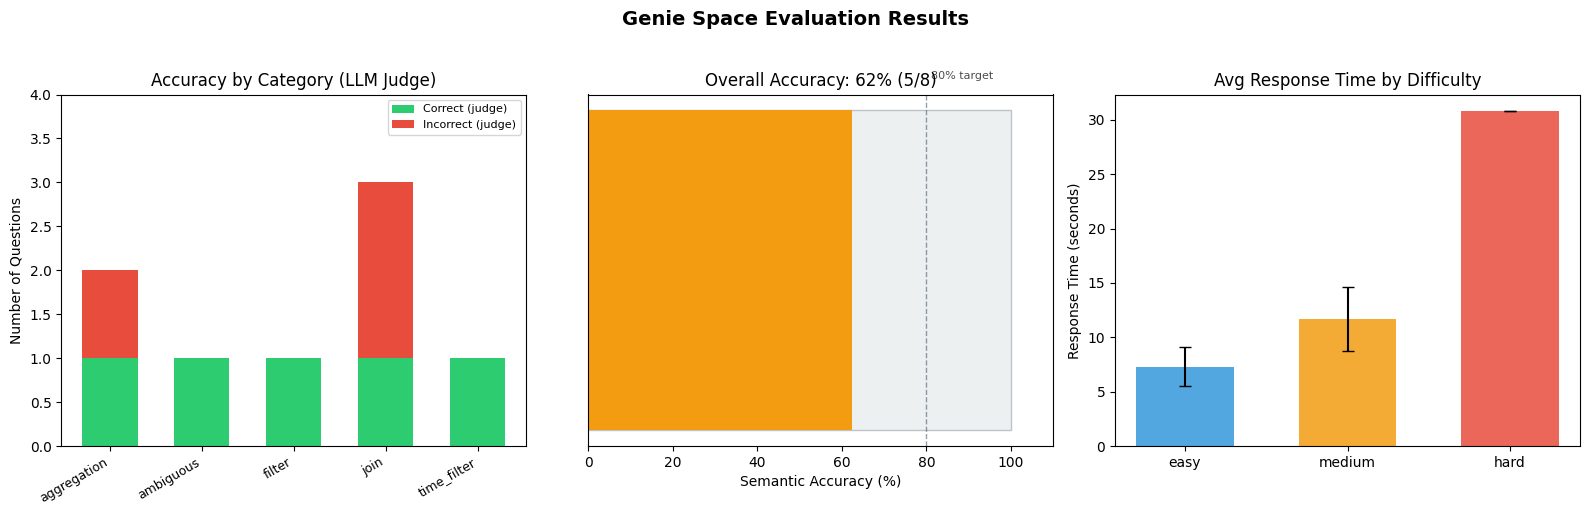


────────────────────────────────────────────────────────────
🎤 Tip: Use these charts in your Genie Space review meetings.
   Compare before/after when you add instructions or example SQL.


In [0]:
# Results Visualization
# =====================
# Visual breakdown of evaluation results by category and difficulty.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Genie Agent Evaluation Results", fontsize=14, fontweight="bold", y=1.02)

# ─── Chart 1: Correct/Incorrect by Category (stacked bar) ────────────────
ax1 = axes[0]
cats = eval_results.groupby("category").agg(
    correct=("judge_correct", lambda x: x.sum()),
    incorrect=("judge_correct", lambda x: (x == False).sum())
)

x_pos = np.arange(len(cats.index))
bar_width = 0.6
ax1.bar(x_pos, cats["correct"], bar_width, color="#2ecc71", label="Correct (judge)")
ax1.bar(x_pos, cats["incorrect"], bar_width, bottom=cats["correct"], color="#e74c3c", label="Incorrect (judge)")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(cats.index, rotation=30, ha="right", fontsize=9)
ax1.set_ylabel("Number of Questions")
ax1.set_title("Accuracy by Category (LLM Judge)")
ax1.legend(loc="upper right", fontsize=8)
ax1.set_ylim(0, max(cats["correct"] + cats["incorrect"]) + 1)

# ─── Chart 2: Accuracy Gauge (horizontal bar) ──────────────────────────
ax2 = axes[1]
total = len(eval_results)
correct_count = int(eval_results["judge_correct"].sum())
rate = correct_count / total * 100 if total > 0 else 0

# Background bar
ax2.barh([0], [100], height=0.5, color="#ecf0f1", edgecolor="#bdc3c7")
# Fill bar — color based on rate
bar_color = "#2ecc71" if rate >= 80 else "#f39c12" if rate >= 50 else "#e74c3c"
ax2.barh([0], [rate], height=0.5, color=bar_color)
ax2.set_xlim(0, 110)
ax2.set_yticks([])
ax2.set_xlabel("Semantic Accuracy (%)")
ax2.set_title(f"Overall Accuracy: {rate:.0f}% ({correct_count}/{total})")
ax2.axvline(x=80, color="#2c3e50", linestyle="--", alpha=0.5, linewidth=1)
ax2.text(81, 0.3, "80% target", fontsize=8, alpha=0.7)

# ─── Chart 3: Response Time by Difficulty ─────────────────────────────
ax3 = axes[2]
diff_order = ["easy", "medium", "hard"]
time_by_diff = eval_results.groupby("difficulty")["execution_time_seconds"].agg(["mean", "std"]).reindex(diff_order).fillna(0)

colors = ["#3498db", "#f39c12", "#e74c3c"]
ax3.bar(range(len(diff_order)), time_by_diff["mean"], color=colors, width=0.6,
        yerr=time_by_diff["std"], capsize=4, alpha=0.85)
ax3.set_xticks(range(len(diff_order)))
ax3.set_xticklabels(diff_order, fontsize=10)
ax3.set_ylabel("Response Time (seconds)")
ax3.set_title("Avg Response Time by Difficulty")

plt.tight_layout()
plt.show()

print("\nTip: Compare before/after runs when you add instructions or example SQL.")

In [0]:
# Single Question Re-test
# =======================
# After identifying a failing question in the results above, use this cell
# to re-test without running the full suite.
#
# Workflow:
#   1. Update your Genie Ontology (add an instruction, example SQL, or join spec)
#   2. Set RETEST_INDEX to the failing test case (0-based index)
#   3. Run this cell to confirm the fix before running the full batch

# ─── Pick a question to re-test ────────────────────────────────────────
# Change the index to re-test a different question from the test suite
RETEST_INDEX = 7  # 0-based: question #8 (complex multi-hop JOIN)

retest_case = test_cases[RETEST_INDEX]
retest_question = retest_case["question"]

print("="*60)
print(" IMPROVEMENT CYCLE — Single Question Re-test")
print("="*60)
print(f"\n  Question: '{retest_question}'")
print(f"  Category: {retest_case['category']} | Difficulty: {retest_case['difficulty']}")
print(f"\n  Sending to Genie...")

retest_result = ask_genie(SPACE_ID, retest_question)
retest_sql = extract_sql(retest_result)

print(f"\n  Status: {retest_result['status']} ({retest_result['elapsed_seconds']}s)")

# ─── Compare with expected ─────────────────────────────────────────────
print("\n  ┌─ Generated SQL ──────────────────────────────────────")
if retest_sql:
    for line in retest_sql.strip().split('\n'):
        print(f"  │  {line}")
else:
    print("  │  (no SQL generated)")
border = "─" * 50
print(f"  └{border}")

print("\n  ┌─ Expected SQL ───────────────────────────────────────")
for line in retest_case['expected_sql'].strip().split('\n'):
    print(f"  │  {line.strip()}")
print(f"  └{border}")

# ─── Quick LLM judge score on this single question ─────────────────────
if retest_sql:
    print("\n  Running LLM judge on this pair...")
    single_eval_data = pd.DataFrame({
        "inputs": [{"question": retest_question}],
        "outputs": [retest_sql],
        "expectations": [{"expected_sql": retest_case['expected_sql'].strip()}],
    })
    single_result = mlflow.genai.evaluate(
        data=single_eval_data,
        scorers=[sql_correctness_judge],
    )
    single_df = single_result.tables["eval_results"]
    judge_value = single_df["sql_semantic_correctness/value"].iloc[0]
    verdict = "✓ PASS" if judge_value else "✗ FAIL"
    print(f"  Judge verdict: {verdict}")
else:
    print("\n  ⚠️  No SQL generated — cannot run judge.")

print("\n" + "─"*60)
print(" 💡 If this FAILED: add an instruction to your Genie Ontology, then")
print("    re-run this cell to see if the score flips to PASS.")
print("    That's the Data Flywheel in action!")

 IMPROVEMENT CYCLE — Single Question Re-test

  Question: 'Which supplier provides ingredients to the franchise with the highest revenue?'
  Category: join | Difficulty: hard

  Sending to Genie...

  Status: COMPLETED (18.69s)

  ┌─ Generated SQL ──────────────────────────────────────
  │  WITH franchise_revenue AS (SELECT `franchiseID`, SUM(`totalPrice`) AS revenue FROM `samples`.`bakehouse`.`sales_transactions` WHERE `franchiseID` IS NOT NULL AND `totalPrice` IS NOT NULL GROUP BY `franchiseID`), ranked_franchises AS (SELECT `franchiseID`, revenue, RANK() OVER (ORDER BY revenue DESC) AS rk FROM franchise_revenue) SELECT f.`name` AS franchise_name, s.`name` AS supplier_name, s.`ingredient`, s.`city`, s.`continent` FROM ranked_franchises rf JOIN `samples`.`bakehouse`.`sales_franchises` f ON rf.`franchiseID` = f.`franchiseID` JOIN `samples`.`bakehouse`.`sales_suppliers` s ON f.`supplierID` = s.`supplierID` WHERE rf.rk = 1 AND f.`supplierID` IS NOT NULL
  └───────────────────────────────

  Judge verdict: ✗ FAIL

────────────────────────────────────────────────────────────
 💡 If this FAILED: add an instruction to your Genie Space, then
    re-run this cell to see if the score flips to PASS.
    That's the Data Flywheel in action!


# Data Flywheel — Next Steps

The evaluation above is not a one-time activity. It’s the **engine** of a continuous improvement loop — the [Data Flywheel](https://www.sh-reya.com/blog/ai-engineering-flywheel/) applied to Genie Agents ("Ask Your Data").

## The Iteration Loop

```
┌─────────────────┐     ┌──────────────────┐     ┌─────────────────┐
│  1. EVALUATE     │ →→→ │  2. IDENTIFY      │ →→→ │  3. IMPROVE       │
│  Run harness    │     │  Find patterns   │     │  Update ontology │
│  Score results  │     │  in failures     │     │  & example SQL   │
└─────────────────┘     └──────────────────┘     └─────────────────┘
        ↑                                               │
        │     ┌──────────────────┐                     │
        └─── │  4. RE-EVALUATE  │ ←←←←←←←←←←←←←←←←←←←←┘
              │  Measure delta   │
              │  Track in MLflow │
              └──────────────────┘
```

## Step-by-Step Process

### 1. Review Failed Questions
Examine the `eval_results` DataFrame above. For each failed or incorrect answer:
- Was the question ambiguous? → Rephrase or add text instructions to the Genie Ontology.
- Did Genie pick the wrong table? → Add join specifications or table descriptions to the ontology.
- Did Genie misinterpret business jargon? → Add a text instruction or synonym defining that term.

### 2. Identify Patterns
Group failures by `category`. Common patterns:
- **Aggregation failures**: Missing metric definitions → Add "When asked about revenue, use SUM(amount)" as an instruction.
- **Filter failures**: Ambiguous column values → Enable `get_example_values` or `build_value_dictionary` on those columns.
- **Join failures**: Genie doesn’t know relationships → Add explicit join specifications.
- **Time-based failures**: Date interpretation issues → Add instructions like "'last month' means the previous calendar month".

### 3. Improve the Genie Ontology
Apply fixes using one of the ontology levers:
- **Text instructions**: Natural-language rules Genie follows.
- **Example SQL**: Question→SQL pairs that teach Genie the expected pattern.
- **Column configurations**: Synonyms, `get_example_values`, `build_value_dictionary` for better filtering.
- **Join specifications**: Explicit join conditions between tables.
- **Prompt matching**: Entity matching + format assistance — helps Genie resolve user terms to actual column values (e.g., “Florida” → `FL`).
- **Trusted assets**: Verified parameterized queries and SQL functions with guaranteed correctness for critical metrics.

### 4. Re-evaluate & Track
Re-run this notebook after each improvement. Each run is logged to MLflow, creating a time series of accuracy scores:

```python
# Compare runs over time (run this in a separate cell)
import mlflow
runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
display(runs[["run_id", "start_time", "params.num_test_cases", "metrics.sql_semantic_correctness/rating/average"]])
```

## Further Reading

For a systematic approach to the improvement workflow — diagnosing failure patterns, choosing the right configuration lever, and avoiding regressions — see the companion blog series:

- [Part 01: The Semantic Layer: Shared Business Meaning as Infrastructure](https://www.databricks.com/blog/semantic-layer-architecture-components-design-patterns-and-ai-integration)
- [Part 02: Managing the Hidden Technical Debt of Generative AI](https://www.databricks.com/blog/hidden-technical-debt-genai-systems)
- [Part 03: Reliable by Design: Building an Evaluation Harness for Databricks Genie](https://www.databricks.com/blog/reliable-by-design-evaluation-harness-databricks-genie)
- [Part 04: Closing the Loop: A Prompt Iteration Workflow for Databricks Genie](#)